# 🧪 Experiment EIMR_081 — Forecast Augmented Hybrid PPO vs Baseline

## 📝 Introduction

In this experiment, we investigate how the candidate policy `ForecastAugmentedHybridPpoPolicy` behaves in an inventory system with multi regime Poisson demand. To assess its value, we compare it against the baseline heuristic `OrderUpToPolicy`.

Beyond overall performance, we also examine how different parameterizations or optimization variants of `ForecastAugmentedHybridPpoPolicy` affect the results.

This leads to the following guiding questions:

- ***RQ1*** – Can a learned `ForecastAugmentedHybridPpoPolicy` policy outperform the simple fixed baseline heuristic `OrderUpToPolicy`?
- ***RQ2*** – How sensitive is the policy’s performance to the chosen parameter settings?

To answer these questions, we follow our standard analytical workflow: define the problem, specify the candidate policies and their variants, evaluate them under **strict CRN**, and compare the results systematically.

If useful, you may extend the analysis by:
- using **Appendix C: Statistical Analysis** for a deeper comparison of two policies, or
- using **Appendix A** to visualize the system dynamics induced by a policy.

We conclude by summarizing the main findings, answering the research questions, and extracting an **exam-relevant takeaway**.

---

**Notes**

- The implementation `ForecastAugmentedHybridPpoPolicy` in `ppo.py` and its descriptive companion document `ppo.md` can be found in `src/inventory/policies/`.
- Repository conventions are documented in [concepts/00_repo_conventions.ipynb](../../../concepts/00_repo_conventions.ipynb).
- If you have trouble running this notebook, first verify your environment in [lectures/00_setup.ipynb](../../../lectures/00_setup.ipynb).

## 📦 Imports

Here we define all required imports to conduct our experiment.

In [15]:
# Imports
import numpy as np

# Optional: in-notebook sanity check (no-op when installed)
from inventory.evaluation.notebooks.bootstrap import ensure_inventory_imports
ensure_inventory_imports(verbose=False)

# Evaluation
from inventory.evaluation import make_eval_info
from inventory.evaluation.notebooks.reports import print_paired_delta_summary
from inventory.evaluation.reporting import summarize_totals

# Plotting
from inventory.evaluation.plotting import plot_multi_regime_sample_path

# Dynamic system framework
from inventory.core.dynamics import DynamicSystem

# Problem definitions
from inventory.problems.inventory_mvp import inventory_cost, inventory_cost_extended, inventory_transition

# Demand model (exogenous)
from inventory.problems.demand_models import ExogenousPoissonMultiRegime

# Forecaster
from inventory.forecasters.ml import MlRegimeDemandForecaster, MultiRegimeFeatureAdapter
from inventory.forecasters.ml import MlAr1RegimeDemandForecaster, MultiRegimeAr1FeatureAdapter
from inventory.forecasters.naive import ConstantMeanForecaster, NaiveForecaster

# Policies
from inventory.policies.baselines import OrderUpToPolicy
from inventory.policies.ppo import (ForecastAugmentedHybridPpoPolicy,PPOHyperParams,HybridPpoPolicy,train_ppo_with_eval_gate,)

---

## 🚧 Problem definition

In this experiment we use our benchmark inventory problem with an constant Poisson demand and our standard set of cost parameters. Keeping this problem definition constant across experiments enables us to compare the effects of different policies.

In [16]:
# === Defining the dynamic system ===

# Simulation horizon
T = 30

# Initial Inventory
# Start in (inventory=300, season=Summer=2, day=Monday=0, weather=Sunny=2)
S0= np.array([300.0, 2.0, 0.0, 2.0], dtype=float)

# Constraints
x_max = 480
dx = 10
S_max = 480

# Exogenous demand
exo = ExogenousPoissonMultiRegime(season_index=1, day_index=2, weather_index=3, season_period=90)

# Cost parameters 
p, c, h, b, K = 2.0, 0.5, 0.03, 1.0, 50.0

# Transition function
transition_func = inventory_transition

# Cost functions
cost_func = lambda s, a, w, t: inventory_cost(s, a, w, t, p=p, c=c, h=h, b=b)
cost_func = lambda s, a, w, t: inventory_cost_extended(s, a, w, t, p=p, c=c, h=h, b=b, K=K)

# Dynamic System
system = DynamicSystem(
    transition_func=transition_func,
    cost_func=cost_func,
    exogenous_model=exo,
    sim_seed=42,
    d_s=4,
    d_x=1,
    d_w=4,
 )

# Strict-CRN Monte Carlo evaluation settings
# PPO is trained/gated under deterministic mean-action evaluation, so keep final CRN evaluation aligned.
seed0 = 1234
n_episodes = 200
eval_info = make_eval_info(T=T, det_mode='argmax') #det_mode='mean'
eval_info

{'deterministic': True, 'det_mode': 'argmax', 'T': 30}

To get an idea about the kind of demand pattern we are dealing with in this problem setting, let us have a lookt at one expamplary demand that matches the CRN “reference episode” seed stream.

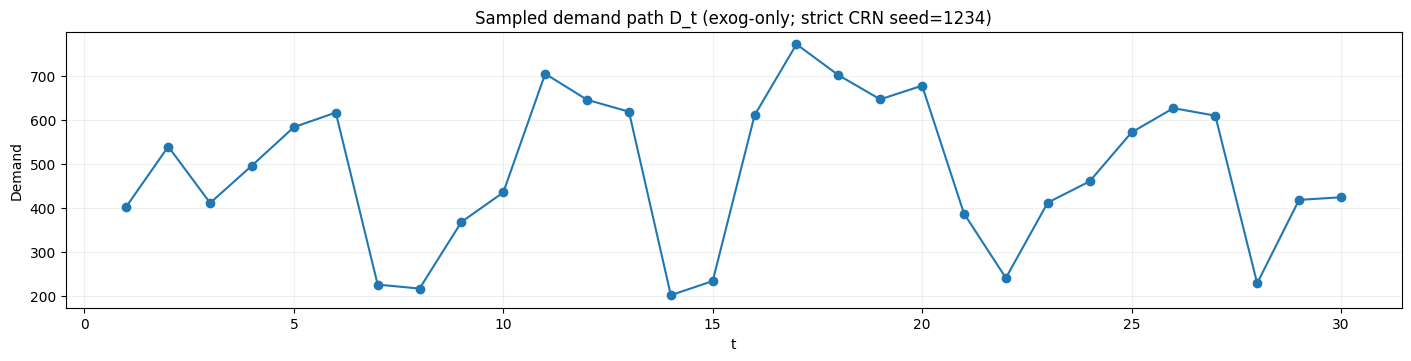

In [17]:
_ = plot_multi_regime_sample_path(exo,T, seed0, state0=S0, figsize=(14, 3.5), demand_only=True)

---

## 🔮 Forecaster defintion

In this section, we specify which information model (a.k.a. **forecaster**) the policy uses to anticipate future demand in the multi-regime setting. We instantiate regime-aware forecaster variants, including a naive forecaster that repeats the last observed demand, a constant-mean forecaster that freezes the current regime-implied demand mean, and a learned ML forecaster trained on synthetic data from the same exogenous model.

Next, we conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [18]:
# === ML Forecaster ===
# Use the regime-aware adapter and forecaster so the model can condition on season, day, and weather.
adapter = MultiRegimeFeatureAdapter(exo)
forecaster_ml = MlRegimeDemandForecaster(adapter, model_type="tree", random_state=0)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml.fit_from_exogenous(
    n_samples=6000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 5
mu_demo = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))

ML forecaster fit_report (summary):
  model_type: tree
  feature_dim: 15
  train: n=6000 | MAE=63.400 | RMSE=82.902 | Bias=-0.000
  val: n=1000 | MAE=65.455 | RMSE=85.690 | Bias=1.988

mu_demo (H=5): [473.96 693.02 598.78 598.78 704.08]


---

## 🤖 Policy definition

In this section, we define the policies under investigation and collect them in a policy dictionary used by our strict-CRN evaluation pipeline.

The first policy is the canonical benchmark `OrderUpTo`. The second policy is the main candidate that we want to compare against this benchmark. The third policy is a controlled variation of the candidate, included to examine one targeted variation of interest.

This set of policies enables a structured comparison and helps us address our research questions.

In [19]:
# === Baseline Policy ===
# Baseline: a fixed order-up-to target
baseline = OrderUpToPolicy(target_level=350.0, x_max=x_max, dx=dx)


In [20]:
# === Candidate Policy ===
# Candidate: PPO actor-critic on the same discrete action grid, with a learned post-decision value function approximation.
# For this PPO implementation, deterministic mean-action evaluation is usually more stable than argmax on the coarse dx-grid.

# Select policy profile to trade off speed vs quality:
profile = "quality"  # "fast" | "quality"

if profile == "fast":
    ppo_hparams = PPOHyperParams(
        gamma=1.0,
        gae_lambda=0.97,
        lr=3e-4,
        clip_eps=0.15,
        vf_coef=0.75,
        ent_coef=0.005,
        n_epochs=4,
        minibatch_size=256,
    )
    total_train_episodes = 300
    chunk_episodes = 100
    gate_eval_episodes = min(100, int(n_episodes))
elif profile == "quality":
    ppo_hparams = PPOHyperParams(
        gamma=1.0,
        gae_lambda=0.97,
        lr=2e-4,
        clip_eps=0.15,
        vf_coef=0.75,
        ent_coef=0.003,
        n_epochs=12,
        minibatch_size=128,
    )
    total_train_episodes = 2400
    chunk_episodes = 300
    gate_eval_episodes = int(n_episodes)
else:
    raise ValueError("Unknown profile")

# Device selection: prefer MPS on macOS if available
device = "cpu"
try:
    import torch
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
except Exception:
    torch = None  # torch might not be installed; HybridPpoPolicy will error on init

# Initialize candidate policy
try:
    candidate = HybridPpoPolicy(
        d_s=int(S0.shape[0]),
        s_max=int(S_max),
        x_max=int(x_max),
        dx=int(dx),
        hidden=256,
        device=device,
        hparams=ppo_hparams,
        seed=0,
        deterministic_eval=False,
    )
except ImportError as e:
    raise RuntimeError(
        "HybridPpoPolicy needs PyTorch. Install it into your environment (e.g. `pip install torch`)."
    ) from e

# Train candidate policy with a simple evaluation gate (accept/reject checkpoints)
do_train = True
if do_train:
    history = train_ppo_with_eval_gate(
        system=system,
        ppo=candidate,
        baseline_policy=baseline,
        S0=S0,
        T=int(T),
        total_train_episodes=int(total_train_episodes),
        chunk_episodes=int(chunk_episodes),
        eval_episodes=int(gate_eval_episodes),
        eval_seed0=int(seed0) + 999,
        train_seed0=int(seed0),
        eval_info=eval_info,
        verbose=True,
    )
    print("\nLast gate record:")
    print(history[-1] if history else None)

[Gate 0] Baseline mean=-5900.535 | PPO mean=14683.480 (lower is better)
[Gate 1] Baseline mean=-5900.535 | Candidate PPO mean=-2220.663 | Best PPO mean=-2220.663 -> ACCEPT
[Gate 2] Baseline mean=-5900.535 | Candidate PPO mean=-10872.092 | Best PPO mean=-10872.092 -> ACCEPT
[Gate 3] Baseline mean=-5900.535 | Candidate PPO mean=-10427.733 | Best PPO mean=-10872.092 -> REJECT
[Gate 4] Baseline mean=-5900.535 | Candidate PPO mean=-11473.008 | Best PPO mean=-11473.008 -> ACCEPT
[Gate 5] Baseline mean=-5900.535 | Candidate PPO mean=-12294.311 | Best PPO mean=-12294.311 -> ACCEPT
[Gate 6] Baseline mean=-5900.535 | Candidate PPO mean=-12377.168 | Best PPO mean=-12377.168 -> ACCEPT
[Gate 7] Baseline mean=-5900.535 | Candidate PPO mean=-12398.045 | Best PPO mean=-12398.045 -> ACCEPT
[Gate 8] Baseline mean=-5900.535 | Candidate PPO mean=-12372.018 | Best PPO mean=-12398.045 -> REJECT

Last gate record:
{'gate': 8, 'baseline_mean': -5900.535249999999, 'candidate_ppo_mean': -12372.01765, 'best_ppo_

In [21]:
# === Controlled Variation of Candidate Policy ===
# Candidate Controlled Variation: same PPO backbone, but with a frozen pretrained forecaster
# that augments the observation with a short forecast mean path.

forecast_horizon = 3
forecast_demand_scale = 100.0

try:
    candidate_var = ForecastAugmentedHybridPpoPolicy(
        forecaster=forecaster_ml,
        raw_state_dim=int(S0.shape[0]),
        forecast_horizon=int(forecast_horizon),
        demand_scale=float(forecast_demand_scale),
        s_max=int(S_max),
        x_max=int(x_max),
        dx=int(dx),
        hidden=256,
        device=device,
        hparams=ppo_hparams,
        seed=0,
        deterministic_eval=False,
    )

except ImportError as e:
    raise RuntimeError(
        "ForecastAugmentedHybridPpoPolicy needs PyTorch. Install it into your environment (e.g. `pip install torch`)."
    ) from e


train_candidate_var = do_train
if train_candidate_var:
    history_var = train_ppo_with_eval_gate(
        system=system,
        ppo=candidate_var,
        baseline_policy=baseline,
        S0=S0,
        T=int(T),
        total_train_episodes=int(total_train_episodes),
        chunk_episodes=int(chunk_episodes),
        eval_episodes=int(gate_eval_episodes),
        eval_seed0=int(seed0) + 999,
        train_seed0=int(seed0) + 50_000,
        eval_info=eval_info,
        verbose=True,
    )
    print("\nLast gate record (forecast-augmented PPO):")
    print(history_var[-1] if history_var else None)


print({
    "forecast_horizon": int(forecast_horizon),
    "forecast_demand_scale": float(forecast_demand_scale),
    "forecaster": type(forecaster_ml).__name__,
})

[Gate 0] Baseline mean=-5900.535 | PPO mean=8359.004 (lower is better)
[Gate 1] Baseline mean=-5900.535 | Candidate PPO mean=-7707.615 | Best PPO mean=-7707.615 -> ACCEPT
[Gate 2] Baseline mean=-5900.535 | Candidate PPO mean=-8646.726 | Best PPO mean=-8646.726 -> ACCEPT
[Gate 3] Baseline mean=-5900.535 | Candidate PPO mean=-8226.924 | Best PPO mean=-8646.726 -> REJECT
[Gate 4] Baseline mean=-5900.535 | Candidate PPO mean=-9143.103 | Best PPO mean=-9143.103 -> ACCEPT
[Gate 5] Baseline mean=-5900.535 | Candidate PPO mean=-7098.767 | Best PPO mean=-9143.103 -> REJECT
[Gate 6] Baseline mean=-5900.535 | Candidate PPO mean=-11977.746 | Best PPO mean=-11977.746 -> ACCEPT
[Gate 7] Baseline mean=-5900.535 | Candidate PPO mean=-12989.211 | Best PPO mean=-12989.211 -> ACCEPT
[Gate 8] Baseline mean=-5900.535 | Candidate PPO mean=-13243.285 | Best PPO mean=-13243.285 -> ACCEPT

Last gate record (forecast-augmented PPO):
{'gate': 8, 'baseline_mean': -5900.535249999999, 'candidate_ppo_mean': -13243.2

In [22]:
# === Collect policies into a dictionary for easy access in evaluation/reporting code ===

policies = {
    'baseline': baseline,
    'candidate': candidate,
    'candidate_var': candidate_var,
}

print('==== Policy Parameters ====')
policies

==== Policy Parameters ====


{'baseline': OrderUpToPolicy(target_level=350.0, x_max=480, dx=10),
 'candidate': HybridPpoPolicy(d_s=4, s_max=480, x_max=480, dx=10, hidden=256, device='mps', seed=0, deterministic_eval=False, gamma=1.0, lr=0.0002, n_epochs=12, minibatch_size=128),
 'candidate_var': ForecastAugmentedHybridPpoPolicy(raw_state_dim=4, forecast_horizon=3, demand_scale=100.0, include_raw_state=True, forecaster='MlRegimeDemandForecaster', s_max=480, x_max=480, dx=10, hidden=256, device='mps', seed=0, deterministic_eval=False, gamma=1.0, lr=0.0002, n_epochs=12, minibatch_size=128)}

---

## 🪄 Experiment run and Strict-CRN policy evaluation

In this section, we evaluate all policies under identical sampled exogenous paths using strict CRN. This ensures a fair comparison and allows us to summarize and illustrate the resulting performance differences.

In [23]:
# === Experiment run and Strict-CRN policy evaluation ===
from inventory.evaluation.notebooks.crn_runs import run_crn_mc

run = run_crn_mc(
    system=system,
    policies=policies,
    S0=S0,
    T=T,
    n_episodes=n_episodes,
    seed0=seed0,
    info=eval_info,
    print_summary=True,
)

results = run.results
rollouts = run.rollouts
totals_by_policy = run.totals_by_policy
totals_summary = run.totals_summary

=== Final CRN-MC totals (lower is better) ===
baseline        | mean=-5852.780 | std=1001.492 | n=200 | runtime=0.264s
candidate       | mean=-12305.879 | std=863.556 | n=200 | runtime=10.606s
candidate_var   | mean=-13129.081 | std=800.886 | n=200 | runtime=11.104s


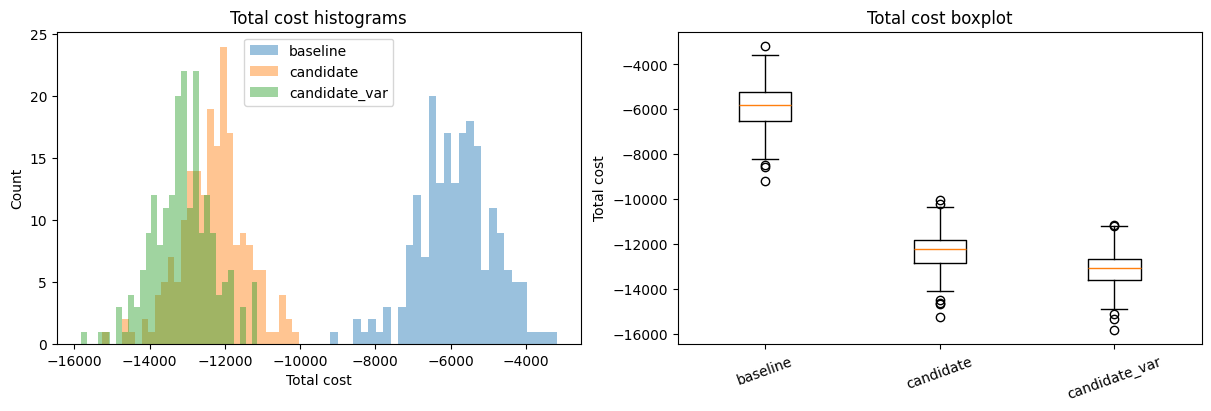

In [24]:
# === Plot total cost distribution and boxplot ===
from inventory.evaluation.plotting import plot_totals_hist_and_box
_ =plot_totals_hist_and_box(totals_by_policy)

## 🔬 Results, Insights & Discussion

In this section, we summarize and interpret the main findings of the experiment in a research-paper style. We first present the key results in compact form, using a result table and a main comparison plot to highlight overall performance differences.

We then discuss what these results teach us by interpreting the baseline–candidate comparison, the default–variation comparison within the candidate class, and their relevance for the underlying modeling question.

Based on this, we answer the research questions directly and conclude with implications and possible next steps.

### What are the main results?
- compact result table
- one main comparison plot
- short interpretation of who performs best
- ***Results 1***: 

### What do we learn?
- interpret baseline vs candidate
- interpret candidate default vs candidate variation
- connect result back to the modeling question
- ***Learning 1***: 

### How would we answer our reseach questions?
- ***RQ1***: 
- ***RQ2***: 

### What next steps would we plan?
- Address implications and next steps
- ***Next step1***:


---

## 🥊 Punchline

In this section, we distill the main punchline of the experiment into an exam-relevant takeaway. Think of it as the “if you remember only two things, remember these” message.


- ***Takeaway 1***: Lorem ipsum

- ***Takeaway 2***: Dolor sit 

---

# Appendix

## 🏎️ Appendix A: Dynamics of the system under policy regimes

In this section, we study the dynamics of the system under the different policy regimes. We first inspect one strict-CRN trajectory for all three policies to compare their actions and resulting system behavior. We then visualize many trajectories together with their mean paths to identify broader dynamic patterns.

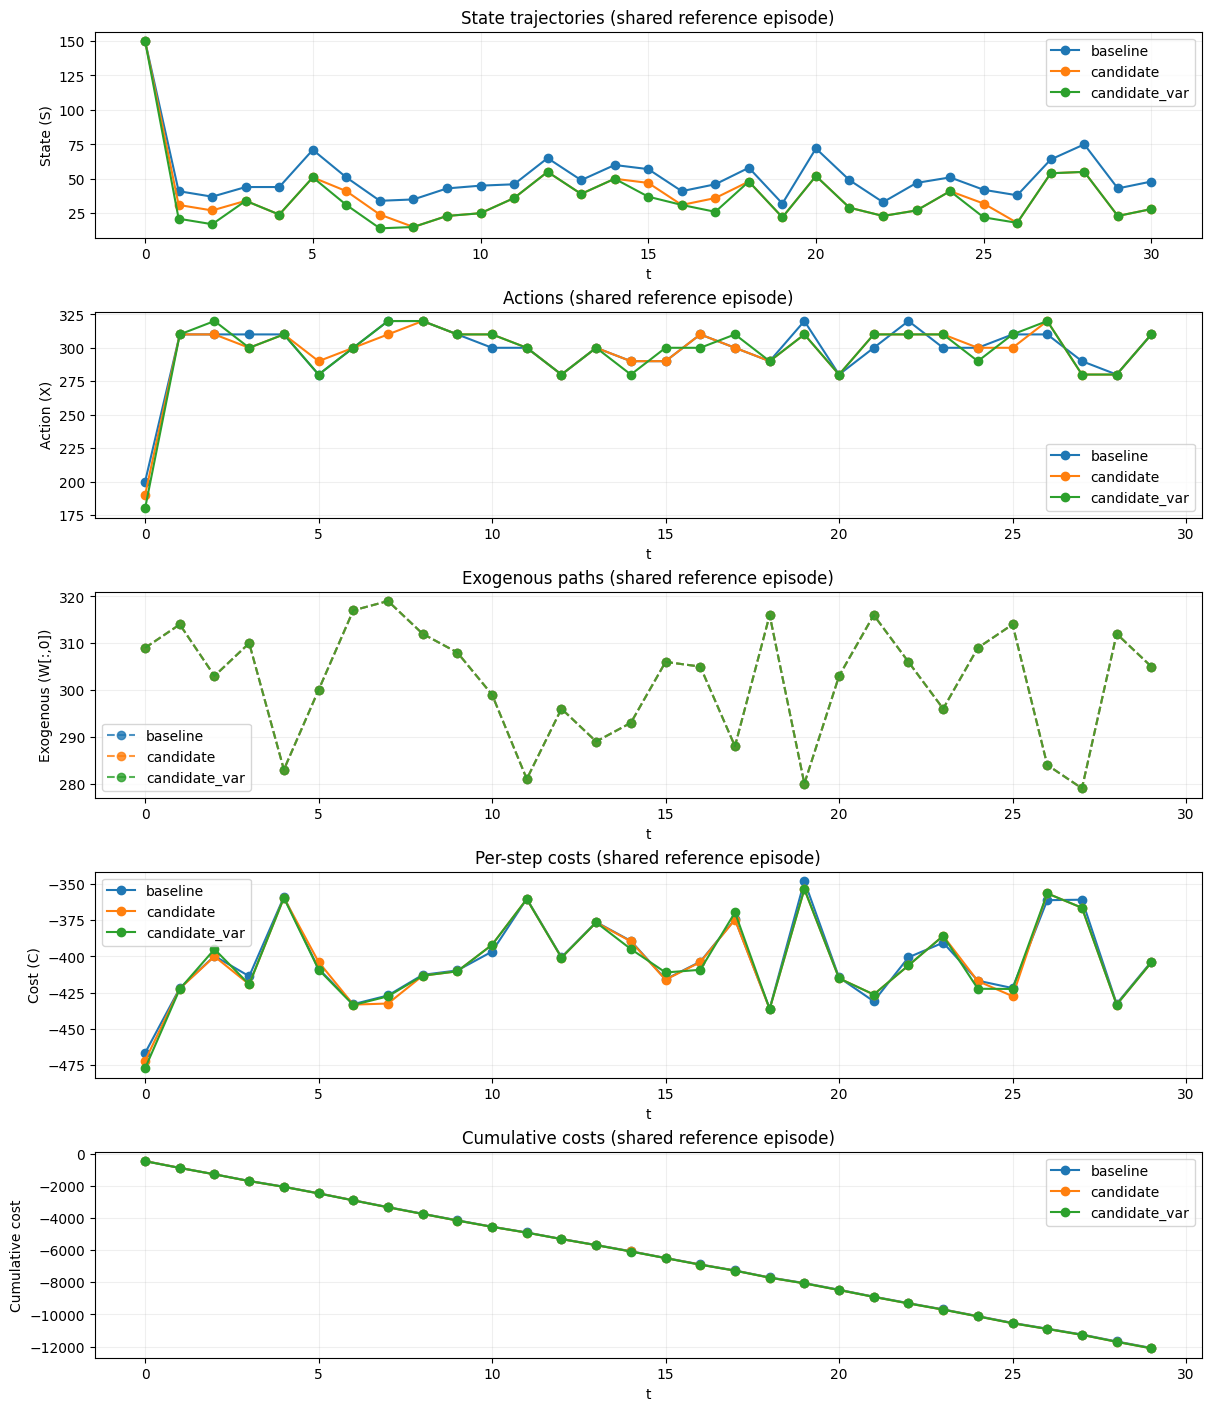

In [ ]:
# === Visual dynamics for one shared *reference episode* per policy ===
from inventory.evaluation.plotting import plot_reference_episode_rollouts_grid
_ = plot_reference_episode_rollouts_grid(
    rollouts,
    figsize=(12, 14),
    show=True,
    marker="o",
 )

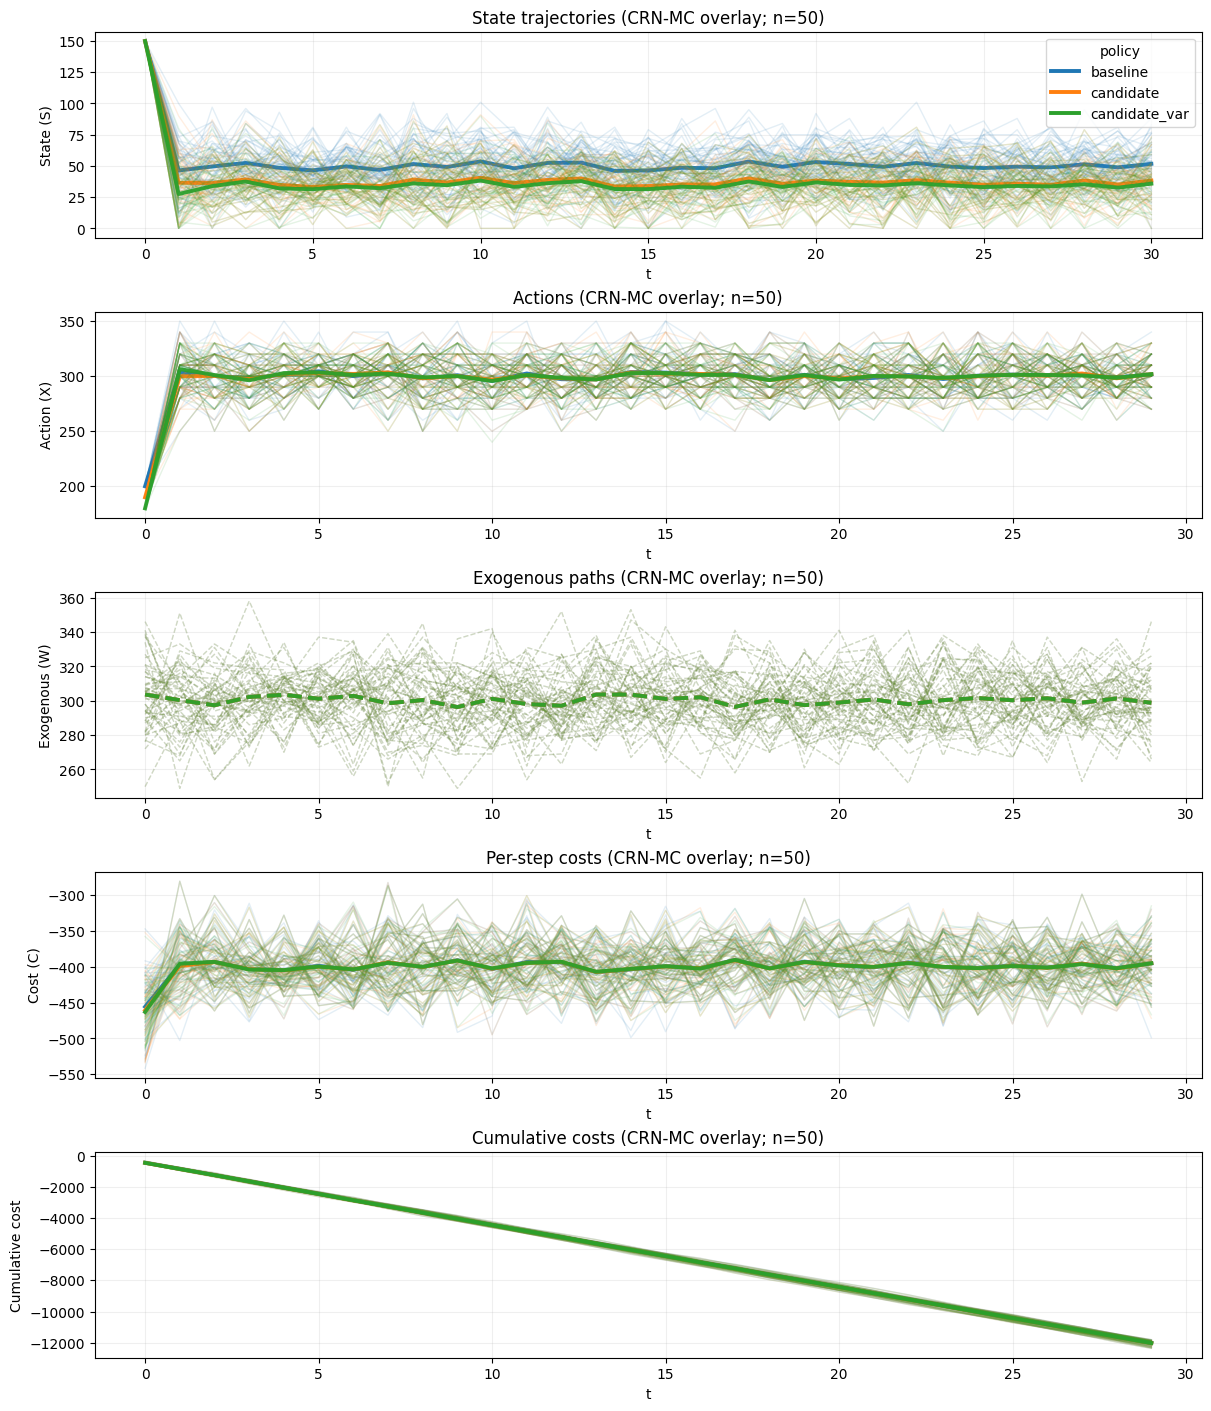

In [ ]:
# === Visual dynamics across many episodes (overlay: faint lines = episodes, bold line = mean) ===

n_plot_episodes = 50

rollouts_mc = system.collect_policies_crn_rollouts_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_plot_episodes,
    seed0=seed0,
    info=eval_info,
 )

from inventory.evaluation.plotting import plot_rollouts_overlay_grid
_ = plot_rollouts_overlay_grid(
    rollouts_mc,
    figsize=(12, 14),
    alpha_episode=0.12,
    linewidth_episode=1.0,
    linewidth_mean=2.8,
    title_suffix=f"(CRN-MC overlay; n={n_plot_episodes})",
    show=True,
 )

---

## 📈 Appendix B: Statistical validation

In this section, we statistically compare two policies in a rigorous and structured way. We begin by defining a baseline policy (the *control*) and a candidate policy (the *treatment*).

Given the hypothesis of interest, we define the paired-delta direction, compute the paired differences, and assess their normality. We then use these paired deltas to perform both a frequentist and a Bayesian hypothesis test.

Finally, we summarize the findings and interpret their meaning in context.

**Notes**

- This appendix supports the statistical comparison of **two** policies only. Multi-policy comparisons require different assumptions and a separate method, which is not implemented here.
- The frequentist and Bayesian hypotheses may differ slightly. They are stated explicitly in their respective sections.

### ⚖️ Paired Delta analysis

Our default hypothesis of interest is that the treatment policy has a positive effect, that is, it achieves a **lower total cost** than the control policy. We therefore compute the paired deltas in the corresponding direction and examine their distribution using a normality diagnostic. This prepares the ground for the subsequent frequentist and Bayesian analyses.


In [27]:
# === Get paired deltas summary ===
from inventory.evaluation.notebooks.reports import print_paired_delta_summary

reports = print_paired_delta_summary(
    totals_by_policy,
    baseline_name="baseline",
    higher_is_better=False,
)

=== Final CRN-MC PairedDeltaReport ===
baseline=baseline   | other=candidate  | mean_delta=-12.112 | std_delta=12.020 | win_rate=0.855 | (lower is better)
baseline=baseline   | other=candidate_var | mean_delta=-10.793 | std_delta=15.845 | win_rate=0.795 | (lower is better)


In [ ]:
# === Calculate paired deltas ===
from inventory.evaluation.notebooks.reports import compute_crn_deltas

# Note: the "other_policy" argument controls which paired deltas are computed (e.g. candidate vs. candidate_var)
crn_deltas = compute_crn_deltas(
    totals_by_policy,
    base_policy="baseline",
    other_policy="candidate",
    plot=False,
)

#crn_deltas[:5], float(crn_deltas.mean())

=== Normality Diagnostics ===
Statistics: n=200, mean=-12.11, std=12.02
Shapiro–Wilk:       stat=0.7714, p=2.322e-16
D’Agostino–Pearson: stat=71.7816, p=2.587e-16
=== Decision at α = 0.05 ===
- At least one test rejects strict normality.
- With n ≈ 1000, even tiny deviations from normality become significant.
- For inference on the mean delta, t-tests/CLT reasoning is often still fine.


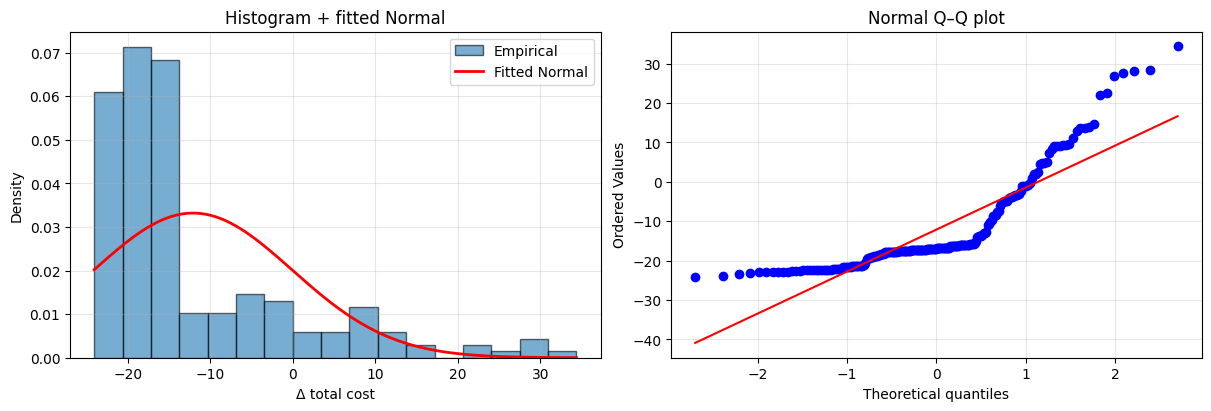

In [32]:
# === Normality diagnostics for paired deltas ===
from inventory.evaluation.deltas import normality_diagnostics
_ = normality_diagnostics(crn_deltas)

---

### ⏱️ Frequentist analysis
In this section, we analyze the policy comparison from a frequentist perspective. Based on the paired deltas, we test whether the observed performance difference is statistically significant under the hypothesis of interest.

Depending on the distribution of the paired differences, we apply an appropriate test and interpret the resulting p-value, test statistic, and confidence interval.

In [35]:
# === Frequentist evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_frequentist_report_for_crn_deltas

_ = print_frequentist_report_for_crn_deltas(crn_deltas)

=== Frequentist CRN Paired-Delta Analysis (Treatment=B vs Control=A) ===
Objective: cost | Delta convention: treatment-control
Delta definition: Δ = Treatment - Control (B - A)
Direction: B better than A ⇔ Δ < 0 | Win-rate rule: B better ⇔ Δ < 0
Claim: B better than A (one-sided, pre-specified)
Alternative used: less | alpha=0.050

--- Hypotheses ---
H0: E[Δ] = 0  (no average difference)
H1: E[Δ] < 0  (B better than A, because B better ⇔ Δ < 0)

--- Descriptives (deltas) ---
n=200 | mean=-12.1122 | median=-16.8600 | std=12.0197 | dz=-1.0077
min=-24.1000 | max=34.3600
win rate (B beats A)=0.8550 (wins=171, losses=29, ties=0)

--- Normality check (Shapiro on deltas) ---
stat=0.7714 | p=0.0000 (<1e-4) | reject@0.050=True

--- Hypothesis tests ---
Paired t-test (Δ vs 0): t=-14.2510 (df=199) | p=0.0000 (<1e-4) | CI(mean)=[-13.7882, -10.4362]
Wilcoxon: W=2053.0000 | p=0.0000 (<1e-4)
Sign test: p=0.0000 (<1e-4) | n_eff=200 (zeros ignored)
Permutation (sign-flip mean): p=0.0000 (<1e-4) (n_perm

### 🔬 Insights

***Frequentist Analysis***

- **Hypothesis**: Here, we formulate the frequentist null and alternative hypotheses for the paired policy comparison.

- **Results**: Here, we report the main outputs of the frequentist test, including the test statistic, p-value, and confidence interval.

- **Interpretation**: Here, we interpret the frequentist results and relate them back to the original policy question.

---

### 🎰 Bayesian analysis
In this section, we examine the policy comparison from a Bayesian perspective. Based on the paired deltas, we estimate the probability that one policy outperforms the other and quantify the uncertainty around the effect. the goal is to assess how credible the observed performance advantage is, how large the effect is likely to be, and what this implies for our decision-making problem.

This complements the frequentist view by focusing on credible effect sizes and probabilistic interpretation rather than statistical significance alone.

In [34]:
# === Bayesian evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_bayesian_report_for_crn_deltas

print_bayesian_report_for_crn_deltas(
    crn_deltas,
    better="lower",
    deltas_are="B_minus_A",
    random_state=0,
    n_draws=200_000,
    cred_level=0.95,
    delta=0.0,
    rope=0.0,
    mode="full",
)

Decision @ 0.95: PASS ✅   P(E[B-A] <= -0) = 1.000
-------------------------------------------------
Bayesian Policy Comparison (paired CRN, episode TOTAL cost)
n episodes: 200
Interpretation: deltas = B - A

Data summary (deltas = B-A):
  sample mean: -12.1122
  sample sd  :  12.0197
  min / max  : -24.1 /  34.36

Posterior on mean treatment effect (E[B-A]):
  95.0% CrI: [-13.6755, -10.3587]
  P(E[B-A] < 0): 1.000
  P(E[B-A] <= -0): 1.000

Verdict:
  Strong evidence: P(E[B-A] <= -0) = 1.000


### 🔬 Insights

***Bayesian Analysis***

- **Hypothesis**: Here, we formulate the Bayesian hypothesis of interest for the paired policy comparison.
- **Results**: Here, we summarize the posterior results, including credible intervals and the probability that one policy outperforms the other.
- **Interpretation**: Here, we interpret the Bayesian findings and discuss what they imply for the policy comparison.

---

## 🚀 Appendix C: Further variatons

In this section, you can explore further variations of the candidate policy to generate additional insights.

To proceed, copy the **Policy Definition** section, modify the policy as needed, and rerun the evaluation pipeline. If appropriate, you may also use the appendices to support a deeper analysis of the new variation.

### 🤖 🪄Additional Policy definition

In [ ]:
# === Copy and adjust 🤖 🪄Additional Policy definition section here ===

### 🪄Additional Experiment run and Strict-CRN policy evaluation

In [ ]:
# === Copy and run 🤖 🪄Additional Experiment run and Strict-CRN policy evaluationsection here ===

### 🏎️ Additional Appendix A: Dynamics of the system under policy regimes section

In [ ]:
# === Copy and run 🏎️ Appendix A: Dynamics of the system under policy regimes section here ===

### 🔍 Additional Appendix B: Statistical validation section 

In [ ]:
# === Copy and run 🔍 Appendix B: Statistical validation section here ===

### 🔬 Additional Insights

In [ ]:
# === Insert 🔬 Additional Insights here ===

---

---

## 🔮 Appendix D: Information model definition

In this section, we specify (if relevant) which information model the policy uses to anticipate future demand. We begin by formulating the forecasting task and explaining why a forecast is needed in this setting. We then describe the training data, including the features and labels used for learning.

Next, we train the selected forecaster variants and conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [ ]:
# === Forecasting task ===
# - what is being predicted?
# - why is forecasting needed here?

In [ ]:
# === Forecaster training data & training ===
# - where the data comes from
# - short explanation of features and labels

# - fit constant / linear / GBDT / MLP / quantile forecaster

In [ ]:
# === Forecaster sanity check ===
# - small plot or a few example predictions

---

## 👨‍🏫 Lecturer Notes

In [ ]:
# det_mode="mean": take the probability-weighted mean action and snap it to the action grid
# det_mode="argmax": take the highest-probability discrete action

In [ ]:
# If you want PPO to behave more like a forecast-aware controller, the clean options are:

# Add forecast features to the observation, for example expected next demand or an H-step forecast path.
# Add history features such as last demand if you want AR behavior.
# Add time-to-go if you want finite-horizon end-of-episode behavior as well.

I’m checking the current notebook state plus the state/transition interfaces so I can describe a concrete observation design that fits this repo, not a generic RL sketch.

Retrieving Notebook summary.

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/core/dynamics.py#1-1), lines 1 to 240

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/core/policy.py)

I have the interface shape. I’m pulling exact anchors for the current raw-observation path and the existing `last_demand` hook so the proposed design is concrete.

Searched for regex `last_demand|step_info\["last_demand"\]|X_t = policy.act\(S_t, t, info=step_info\)` (`**/src/inventory/core/dynamics.py`), 6 results

Searched for regex `self.d_s = int\(d_s\)|self.net = _ActorCriticNet\(self.d_s, self.n_a|s_t = self._state_tensor\(state\)` (`**/src/inventory/policies/ppo.py`), 3 results

The clean version is: keep the environment state as-is, but give PPO a richer observation vector than the raw 4-state input it currently uses.

Right now `HybridPpoPolicy` takes the raw state dimension `d_s` and feeds that straight into the network in ppo.py, ppo.py, and ppo.py. In this notebook the raw state is still just `S = [inventory, season, day, weather]` with `d_s=4`, as configured in EIIMR_080_HybridPpoPolicy_vs_baseline.ipynb and EIIMR_080_HybridPpoPolicy_vs_baseline.ipynb. The dynamics layer already passes `last_demand` through `info` at each step in dynamics.py, so you already have one useful hook for richer observations.

For forecast augmentation, I would build an observation like
$$
o_t = \big[I_t,\ \text{season}_t,\ \text{day}_t,\ \text{weather}_t,\ \mu_{t+1|t},\mu_{t+2|t},\mu_{t+3|t},\ \sigma_{t+1|t},\sigma_{t+2|t},\sigma_{t+3|t}\big]
$$
where each $\mu_{t+k|t}$ is the expected demand $k$ steps ahead under the current regime state and the regime transition matrices, and each $\sigma_{t+k|t}$ is an uncertainty proxy. In your multi-regime Poisson model, the current regime coordinates are already read from state in demand_models.py, and expected demand for a regime tuple comes from `lambda_for_regimes(...)` in demand_models.py.

Concretely, for a short horizon \(H=3\), a good first observation would be:
```python
obs_t = np.array([
    inventory / S_max,
    season / 3.0,
    day / 6.0,
    weather / 2.0,
    mu_1 / demand_scale,
    mu_2 / demand_scale,
    mu_3 / demand_scale,
    np.sqrt(mu_1) / demand_scale,
    np.sqrt(mu_2) / demand_scale,
    np.sqrt(mu_3) / demand_scale,
], dtype=np.float32)
```

The implementation shape I’d recommend is a small observation builder, then a PPO variant that uses it instead of raw state:

```python
class MultiRegimeForecastObservation:
    def __init__(self, exo, horizon=3, s_max=480, demand_scale=100.0):
        self.exo = exo
        self.horizon = int(horizon)
        self.s_max = float(s_max)
        self.demand_scale = float(demand_scale)

    def _expected_lambdas(self, state: np.ndarray, t: int) -> np.ndarray:
        season = int(round(state[self.exo.season_index]))
        day = int(round(state[self.exo.day_index]))
        weather = int(round(state[self.exo.weather_index]))

        p_season = np.zeros(self.exo.P_season.shape[0]); p_season[season] = 1.0
        p_day = np.zeros(self.exo.P_day.shape[0]); p_day[day] = 1.0
        p_weather = np.zeros(self.exo.P_weather.shape[0]); p_weather[weather] = 1.0

        mus = []
        for k in range(1, self.horizon + 1):
            p_day = p_day @ self.exo.P_day
            p_weather = p_weather @ self.exo.P_weather

            if self.exo.season_period > 0 and ((t + k) % self.exo.season_period == 0):
                p_season = p_season @ self.exo.P_season

            mu_k = 0.0
            for rs, ps in enumerate(p_season):
                for rd, pd in enumerate(p_day):
                    for rw, pw in enumerate(p_weather):
                        mu_k += ps * pd * pw * self.exo.lambda_for_regimes(rs, rd, rw)
            mus.append(mu_k)
        return np.asarray(mus, dtype=np.float32)

    def __call__(self, state: np.ndarray, t: int, info: dict | None = None) -> np.ndarray:
        state = np.asarray(state, dtype=np.float32)
        mus = self._expected_lambdas(state, t)
        sigmas = np.sqrt(mus)

        return np.concatenate([
            np.array([
                state[0] / self.s_max,
                state[self.exo.season_index] / 3.0,
                state[self.exo.day_index] / 6.0,
                state[self.exo.weather_index] / 2.0,
            ], dtype=np.float32),
            mus / self.demand_scale,
            sigmas / self.demand_scale,
        ])
```

Then PPO changes are minimal in spirit:
```python
class ForecastAugmentedHybridPpoPolicy(HybridPpoPolicy):
    def __init__(self, *, obs_builder, d_obs: int, **kwargs):
        super().__init__(d_s=d_obs, **kwargs)
        self.obs_builder = obs_builder

    def _state_tensor(self, state, t=0, info=None):
        obs = self.obs_builder(state, t, info)
        obs = self.norm.normalize(np.asarray(obs, dtype=np.float32))
        return torch.tensor(obs, dtype=torch.float32, device=self.device)

    def act(self, state, t, info=None):
        info = info or {}
        inv = float(np.asarray(state, dtype=float).reshape(-1)[0])
        with torch.no_grad():
            s_t = self._state_tensor(state, t=t, info=info)
            logits, _ = self.net(s_t)
            logits = self._masked_logits(logits, inv)
            ...
```

And in training, wherever the current PPO stores `s_t_np = traj[tt].astype(np.float32)`, you would instead store:
```python
obs_t_np = self.obs_builder(traj[tt], tt, info_for_that_step).astype(np.float32)
```

The key design choice is what forecast features to append. For this repo, I would start with these three only:

1. `mu_1, mu_2, mu_3`: expected demand over the next 3 steps.
2. `sqrt(mu_1), sqrt(mu_2), sqrt(mu_3)`: Poisson uncertainty proxies.
3. `last_demand`: because the dynamics layer already provides it via `info`.

So the first practical observation vector would be:
$$
o_t = [I_t,\ r^{season}_t,\ r^{day}_t,\ r^{weather}_t,\ \mu_{1},\mu_{2},\mu_{3},\sqrt{\mu_1},\sqrt{\mu_2},\sqrt{\mu_3}, d_{t-1}]
$$

That gives PPO something forecaster-like without forcing it to learn the regime transition algebra from scratch.

If you want, the next useful step is for me to implement this as a new policy class, for example `ForecastAugmentedHybridPpoPolicy`, and wire one comparison cell into EIIMR_080_HybridPpoPolicy_vs_baseline.ipynb.

I’m checking how the CFA policy consumes a forecaster so I can compare that pattern directly against PPO rather than answer at the level of opinion.

Searched for regex `class OrderMilpCfaPolicy|forecaster|forecast_mean_path|mu_hat|forecast` (`**/src/inventory/policies/**/*.py`), 120 results

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/policies/alphazero.py#240-240), lines 240 to 360

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/policies/ppo.py#90-90), lines 90 to 220

I’ve confirmed the structural difference: CFA consumes a forecaster as the decision model, whereas PPO currently consumes only raw features. I’m pulling the exact CFA integration points so I can explain where injecting a forecaster into PPO makes sense and where it does not.

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/policies/cfa_milp.py#1-1), lines 1 to 130

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/policies/cfa_milp.py#130-130), lines 130 to 220

Searched for regex `def _featurize\(|self\.d_in =|state\[1\]|time_features` (`**/src/inventory/policies/alphazero.py`), 8 results

No, that is not a stupid idea. It is a good idea, with one important caveat: for PPO, the forecaster should usually be used as a feature generator, not as the decision rule itself.

That is the key difference from the CFA pattern. In cfa_milp.py, OrderMilpCfaPolicy is explicitly a forecast-then-optimize controller: it asks a forecaster for a horizon path in cfa_milp.py, then solves the optimization model from that path in cfa_milp.py. PPO is different. Its network just maps an input vector to action logits and a value in ppo.py, ppo.py, and ppo.py. So for PPO, the natural analogue is not “let the forecaster choose the action”, but “let the forecaster enrich the observation”.

So the strong version of the idea is:

1. Keep the forecaster frozen.
2. At each decision time, call the forecaster with the current state.
3. Append forecast outputs to the PPO observation.
4. Let PPO learn how to use those forecast features.

That is often better than forcing PPO to rediscover the demand structure from raw state alone. In fact, your current AlphaZero featurization is still very thin: it uses inventory, one regime coordinate, and time features in alphazero.py and alphazero.py. It does not currently expose the full multi-regime state structure directly. So richer forecast-driven features are a serious modeling upgrade, not decoration.

The clean PPO design would look like this:

1. Add an optional forecaster argument to the PPO class.
2. Replace the raw state tensor builder with an observation builder.
3. If a forecaster is present, compute forecast features and concatenate them to the raw state.
4. Train and evaluate PPO on that same augmented observation.

Conceptually:
$$
o_t = [S_t,\ \mu_{t+1|t},\mu_{t+2|t},\ldots,\mu_{t+H|t}]
$$

or, better:
$$
o_t = [S_t,\ \mu_{1:H},\ \sigma_{1:H},\ d_{t-1}]
$$

where:
1. S_t is the raw state.
2. \mu_{1:H} is the forecast mean path.
3. \sigma_{1:H} is an uncertainty path if available.
4. d_{t-1} is last demand.

In this repo, the dynamics layer already passes last_demand through info in dynamics.py, so that part is already available.

What I would not recommend is the stronger hybrid:
1. Forecaster produces a path.
2. PPO somehow directly optimizes against that path internally like a CFA.
3. PPO action becomes partly hard-coded by the forecast logic.

That tends to blur the architecture and gives you the worst of both worlds: a policy-gradient learner plus hand-built planning logic inside it. If you want forecast-then-optimize, CFA or MPC is the cleaner family. If you want learned control, PPO with forecast-augmented observations is the cleaner family.

The main risks are practical, not conceptual:

1. Train/eval mismatch.
Use the same forecaster and the same feature construction during training and evaluation.

2. Stochastic forecasts.
If the forecaster is stochastic, feed PPO a deterministic summary such as mean path, quantiles, or mean plus std. Do not give it a fresh random sampled path each time unless that is a deliberate design choice.

3. Scale mismatch.
Forecast features need normalization, otherwise large demand values can dominate the raw state features.

4. Information leakage.
The forecaster must only use information available at decision time. No future regime realizations, no future demand.

5. Frozen versus jointly trained.
Start frozen. Jointly training the forecaster and PPO is possible, but it is much harder to debug and much easier to destabilize.

So my recommendation is:

1. Yes, passing a pretrained forecaster to PPO is a sensible design.
2. Use it to build observation features, not to replace PPO’s action logic.
3. Freeze it first.
4. Start with mean-path features over a short horizon, for example H = 3 or H = 5.

If you want, I can implement the clean version next as a new policy class, for example ForecastAugmentedHybridPpoPolicy, rather than mutating HybridPpoPolicy directly.